# DOUBLE LASSO REPLICATION - FRANCE GENDER WAGE GAP DATA

By Vladislava Anashkina

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
import patsy
import warnings
warnings.simplefilter("ignore")
np.random.seed(1234)

In [2]:
!pip install awscli

In [3]:
!pip install --upgrade pip

In [4]:
!aws --version

aws-cli/1.44.53 Python/3.13.8 Linux/5.15.0-164-generic botocore/1.42.63


In [5]:
df = pd.read_csv("sample_dataset (1).txt")

,A6,A17,A38,CPFD,DATDEB,DATFIN,DEPR,DEPT,DOMEMPL,DOMEMPL_EM,...,CONT_TRAV,CS,AGE_TR,DATDEB_TR,DATFIN_TR,DUREE_TR,POND,annual_wage_euro,y,female
0,BE,C5,CG,C,1.0,360.0,49,49,9.0,9.0,...,CDI,67.0,47.0,1.0,12.0,12.0,12,21000.0,9.952278,0
1,BE,C5,CG,C,1.0,360.0,59,59,9.0,9.0,...,CDI,38.0,47.0,1.0,12.0,12.0,12,32500.0,10.388995,0
2,BE,C5,CG,C,1.0,360.0,66,66,9.0,9.0,...,CDI,62.0,47.0,1.0,12.0,12.0,12,21000.0,9.952278,0
3,BE,C5,CG,C,1.0,360.0,72,72,9.0,9.0,...,CDI,54.0,47.0,1.0,12.0,12.0,12,21000.0,9.952278,1
4,BE,C5,CG,C,1.0,360.0,75,92,9.0,9.0,...,CDI,37.0,47.0,1.0,12.0,12.0,12,70000.0,11.156251,0


In [6]:
print(df.columns)

Index(['A6', 'A17', 'A38', 'CPFD', 'DATDEB', 'DATFIN', 'DEPR', 'DEPT',
       'DOMEMPL', 'DOMEMPL_EM', 'DUREE', 'FILT', 'REGR', 'REGT', 'SEXE', 'PCS',
       'TYP_EMPLOI', 'CONV_COLL', 'NBHEUR', 'NBHEUR_TOT', 'AGE', 'TRNNETO',
       'TRALCHT', 'TREFF', 'CONT_TRAV', 'CS', 'AGE_TR', 'DATDEB_TR',
       'DATFIN_TR', 'DUREE_TR', 'POND', 'annual_wage_euro', 'y', 'female'],
      dtype='object')


# Define outcome & base dataframe

In [10]:
import numpy as np
import pandas as pd

# Copy data
df_clean = df.copy()

# Keep only observations below the income cutoff 
df_clean = df_clean[df_clean["y"] < 10.3889953683178].copy()

# Optional: reset index
df_clean = df_clean.reset_index(drop=True)

print(df.shape, "->", df_clean.shape)

(762661, 34) -> (463882, 34)


In [11]:
y = df_clean["y"].astype(float).values
Z = df_clean.drop(columns=["y", "annual_wage_euro"]).copy()

cat_cols = [
    "A6", "A17", "A38", "CPFD", "DEPR", "DEPT",
    "DOMEMPL", "DOMEMPL_EM", "FILT", "REGR", "REGT",
    "SEXE", "PCS", "TYP_EMPLOI", "CONV_COLL",
    "TRNNETO", "TRALCHT", "CONT_TRAV", "CS",
    "AGE_TR", "DATDEB_TR", "DATFIN_TR", "DUREE_TR", "TREFF"
]

for c in cat_cols:
    if c in Z.columns:
        Z[c] = Z[c].astype("category")

Z["female"] = Z["female"].astype(float)

# Feature Engeneering

#### Use a moderate control set with interactions, and keep high-cardinality variables without interactions.

In [12]:
X = patsy.dmatrix(
    '0'
    ' + (AGE + NBHEUR + DUREE)**2'
    ' + C(A6) + C(CS) + C(CONT_TRAV) + C(REGR)'
    ' + female'
    ' + female:(AGE + NBHEUR + DUREE'
    ' + C(A6) + C(CS) + C(CONT_TRAV) + C(REGR))',
    Z,
    return_type='dataframe'
)

# Keep only heterogeneous-effect terms
interaction_cols = [c for c in X.columns if c.startswith("female:")]

# Optional checks
print("X shape:", X.shape)
print("Number of interaction terms:", len(interaction_cols))
print(interaction_cols)

X shape: (463882, 113)
Number of interaction terms: 54
['female:C(A6)[T.BE]', 'female:C(A6)[T.FZ]', 'female:C(A6)[T.GI]', 'female:C(A6)[T.JU]', 'female:C(A6)[T.OQ]', 'female:C(CS)[T.21.0]', 'female:C(CS)[T.22.0]', 'female:C(CS)[T.23.0]', 'female:C(CS)[T.31.0]', 'female:C(CS)[T.33.0]', 'female:C(CS)[T.34.0]', 'female:C(CS)[T.35.0]', 'female:C(CS)[T.37.0]', 'female:C(CS)[T.38.0]', 'female:C(CS)[T.42.0]', 'female:C(CS)[T.43.0]', 'female:C(CS)[T.44.0]', 'female:C(CS)[T.45.0]', 'female:C(CS)[T.46.0]', 'female:C(CS)[T.47.0]', 'female:C(CS)[T.48.0]', 'female:C(CS)[T.52.0]', 'female:C(CS)[T.53.0]', 'female:C(CS)[T.54.0]', 'female:C(CS)[T.55.0]', 'female:C(CS)[T.56.0]', 'female:C(CS)[T.62.0]', 'female:C(CS)[T.63.0]', 'female:C(CS)[T.64.0]', 'female:C(CS)[T.65.0]', 'female:C(CS)[T.67.0]', 'female:C(CS)[T.68.0]', 'female:C(CS)[T.69.0]', 'female:C(CONT_TRAV)[T.CDI]', 'female:C(REGR)[T.2.0]', 'female:C(REGR)[T.3.0]', 'female:C(REGR)[T.4.0]', 'female:C(REGR)[T.11.0]', 'female:C(REGR)[T.24.0]', 'fema

# Double Lasso and Neyman Orthogonality

This section implements the **Double Lasso (or partialling-out) estimator** to estimate heterogeneous effects in a high-dimensional setting. The method follows the framework developed by Belloni, Chernozhukov, and Hansen and described in the lecture slides on Double (Post) Lasso.

---

# 1. The High-Dimensional Causal Model

We are interested in estimating the causal effect of a treatment variable $D$ on an outcome $Y$ while controlling for many covariates $W$:

$$
Y_i = \alpha D_i + \beta' W_i + \varepsilon_i
$$

where

- $Y_i$: outcome variable (e.g., log wages)  
- $D_i$: treatment variable (here interactions such as `female × X`)  
- $W_i$: high-dimensional set of controls  
- $\alpha$: parameter of interest  

The causal interpretation relies on the **conditional independence assumption**:

$$
Y(1), Y(0) \perp D \mid W
$$

meaning that once we control for $W$, treatment assignment is independent of potential outcomes.

However, when $W$ is high-dimensional, standard OLS becomes unreliable due to **overfitting and variable selection issues**.

---

# 2. Frisch–Waugh–Lovell and Partialling Out

A key idea behind the estimator is the **Frisch–Waugh–Lovell theorem**.

Suppose we estimate:

$$
Y = X_1 \beta_1 + X_2 \beta_2 + u
$$

The theorem states that the coefficient $\beta_1$ can be obtained by:

1. Regressing $Y$ on $X_2$ and computing residuals  
2. Regressing $X_1$ on $X_2$ and computing residuals  
3. Regressing the residualized outcome on the residualized regressor  

$$
\tilde{Y} = \alpha \tilde{D} + \varepsilon
$$

where

$$
\tilde{Y} = Y - E[Y|W], \quad
\tilde{D} = D - E[D|W]
$$

This partialling-out approach isolates the variation in $D$ that is **not explained by the controls**.

---

# 3. Why Lasso is Needed

In many empirical applications:

$$
p = \text{number of controls} \gg n
$$

Thus we assume **approximate sparsity**:

- Only a small subset of controls strongly affects the outcome  
- Many variables have small or negligible effects  

The Lasso estimator performs **variable selection and shrinkage**, solving:

$$
\hat{\gamma} =
\arg\min_\gamma
\sum_i (Y_i - W_i'\gamma)^2
+
\lambda \sum_j |\gamma_j|
$$

The penalty parameter $\lambda$ controls the number of variables selected.

---

# 4. The Double Lasso Algorithm

The Double Lasso estimator proceeds in three steps.

### Step 1: Predict the outcome

Estimate

$$
Y_i = g(W_i) + u_i
$$

using Lasso and compute residuals:

$$
\tilde{Y}_i = Y_i - \hat{g}(W_i)
$$

---

### Step 2: Predict the treatment

Estimate

$$
D_i = m(W_i) + v_i
$$

using Lasso and compute residuals:

$$
\tilde{D}_i = D_i - \hat{m}(W_i)
$$

---

### Step 3: Final regression

Estimate the causal effect using the residualized variables:

$$
\tilde{Y}_i = \alpha \tilde{D}_i + \varepsilon_i
$$

This corresponds exactly to the final regression step implemented in the code.

---

# 5. Moment Conditions

The estimator can also be written as solving the moment condition

$$
E[(\tilde{Y} - \alpha \tilde{D})\tilde{D}] = 0
$$

which yields

$$
\alpha =
(E[\tilde{D}^2])^{-1} E[\tilde{D}\tilde{Y}]
$$

This representation highlights that the estimator depends on **nuisance parameters** (the functions predicting $Y$ and $D$).

---

# 6. Neyman Orthogonality

A central property that makes the estimator valid is **Neyman orthogonality**.

Let $\eta$ denote the nuisance parameters (the functions predicting $Y$ and $D$).

The parameter $\alpha$ is Neyman orthogonal if

$$
\frac{\partial \alpha(\eta_0)}{\partial \eta} = 0
$$

Equivalently, the moment condition satisfies

$$
\frac{\partial M(\alpha, \eta_0)}{\partial \eta} = 0
$$

This means that **small estimation errors in the nuisance parameters do not affect the first-order behavior of the estimator**.

This property is crucial because machine learning methods (such as Lasso) may converge slowly, yet the estimator of $\alpha$ still achieves the standard $\sqrt{n}$ convergence rate.

---

# 7. Heterogeneous Treatment Effects

In this application we estimate heterogeneous gender effects.

The model includes interaction terms:

$$
Y_i =
\beta \cdot Female_i +
\sum_j \alpha_j (Female_i \times X_{ij}) +
f(X_i) + \varepsilon_i
$$

Each coefficient $\alpha_j$ measures how the **gender wage gap varies with characteristic $X_j$**.

The code estimates each coefficient using **one-by-one double lasso**, treating all other interactions as controls.

---

# 8. Inference

Under approximate sparsity and regularity conditions,

$$
\sqrt{n}(\hat{\alpha} - \alpha)
\rightarrow N(0, V)
$$

with

$$
V =
(E[\tilde{D}^2])^{-1}
E[\tilde{D}^2 \varepsilon^2]
(E[\tilde{D}^2])^{-1}
$$

This allows valid **standard errors and confidence intervals**, even in high-dimensional settings.

---

# 9. Interpretation

The estimated coefficients measure **how socio-economic characteristics modify the gender wage gap**.

For example:

- Positive coefficient → larger gender wage gap  
- Negative coefficient → smaller gender wage gap  

The method therefore identifies **which characteristics explain heterogeneity in the gender wage gap** while controlling for many potential confounders.

In [13]:
!pip install multiprocess

In [14]:
!git clone https://github.com/maxhuppertz/hdmpy.git

fatal: destination path 'hdmpy' already exists and is not an empty directory.


In [15]:
import sys
sys.path.insert(1, "./hdmpy")

In [16]:
import hdmpy
print(dir(hdmpy))

['LassoShooting_fit', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'cor', 'cvec', 'get_cov', 'help_functions', 'init_values', 'lambdaCalculation', 'rlasso', 'rlassoEffect', 'rlassoEffect_wrapper', 'rlassoEffects', 'simul_ci', 'simul_pen']


In [17]:
import numpy as np
from sklearn.base import BaseEstimator

# Wrap hdmpy so it behaves like an sklearn-style estimator
class RLasso(BaseEstimator):
    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        self.rlasso_ = hdmpy.rlasso(X, y, post=self.post)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        beta = np.asarray(self.rlasso_.est["beta"]).ravel()
        intercept = float(np.asarray(self.rlasso_.est["intercept"]).ravel()[0])
        return X @ beta + intercept

def lasso_model():
    return RLasso(post=False)

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

# Ensure numeric matrix
X = X.astype(float)

alpha = {}
res_y = {}
res_D = {}
epsilon = {}

# Double lasso loop
for c in interaction_cols:
    print(f"Double Lasso for target variable: {c}")

    D = X[c].values.astype(float)
    W = X.drop(columns=[c]).astype(float)

    # Residualize y on W
    res_y[c] = y - lasso_model().fit(W, y).predict(W)

    # Residualize D on W
    res_D[c] = D - lasso_model().fit(W, D).predict(W)

    # Final low-dimensional regression
    final = LinearRegression(fit_intercept=False).fit(
        res_D[c].reshape(-1, 1),
        res_y[c]
    )

    epsilon[c] = res_y[c] - final.predict(res_D[c].reshape(-1, 1))

    # store point estimate
    alpha[c] = [final.coef_[0]]

# Covariance matrix
V = np.zeros((len(interaction_cols), len(interaction_cols)))

for it, c in enumerate(interaction_cols):
    Jc = np.mean(res_D[c] ** 2)

    for itp, cp in enumerate(interaction_cols):
        Jcp = np.mean(res_D[cp] ** 2)
        Sigma = np.mean(res_D[c] * epsilon[c] * epsilon[cp] * res_D[cp])
        V[it, itp] = Sigma / (Jc * Jcp)

# Standard errors
n = X.shape[0]
for it, c in enumerate(interaction_cols):
    alpha[c] += [np.sqrt(V[it, it] / n)]

# Put all in a dataframe
results_dl = pd.DataFrame.from_dict(
    alpha,
    orient="index",
    columns=["point", "stderr"]
)

results_dl.index.name = "term"
results_dl = results_dl.reset_index()

# p-values and confidence intervals
summary = pd.DataFrame()
summary["term"] = results_dl["term"]
summary["Estimate"] = results_dl["point"]
summary["Std. Error"] = results_dl["stderr"]
summary["p-value"] = 2 * norm.sf(np.abs(results_dl["point"] / results_dl["stderr"]))
summary["ci_lower"] = results_dl["point"] - 1.96 * results_dl["stderr"]
summary["ci_upper"] = results_dl["point"] + 1.96 * results_dl["stderr"]

summary = summary.sort_values("term").reset_index(drop=True)
summary

Double Lasso for target variable: female:C(A6)[T.BE]
Double Lasso for target variable: female:C(A6)[T.FZ]
Double Lasso for target variable: female:C(A6)[T.GI]
Double Lasso for target variable: female:C(A6)[T.JU]
Double Lasso for target variable: female:C(A6)[T.OQ]
Double Lasso for target variable: female:C(CS)[T.21.0]
Double Lasso for target variable: female:C(CS)[T.22.0]
Double Lasso for target variable: female:C(CS)[T.23.0]
Double Lasso for target variable: female:C(CS)[T.31.0]
Double Lasso for target variable: female:C(CS)[T.33.0]
Double Lasso for target variable: female:C(CS)[T.34.0]
Double Lasso for target variable: female:C(CS)[T.35.0]
Double Lasso for target variable: female:C(CS)[T.37.0]
Double Lasso for target variable: female:C(CS)[T.38.0]
Double Lasso for target variable: female:C(CS)[T.42.0]
Double Lasso for target variable: female:C(CS)[T.43.0]
Double Lasso for target variable: female:C(CS)[T.44.0]
Double Lasso for target variable: female:C(CS)[T.45.0]
Double Lasso for tar

,term,Estimate,Std. Error,p-value,ci_lower,ci_upper
0,female:AGE,0.000344,0.000047,3.108336e-13,0.000251,0.000436
1,female:C(A6)[T.BE],0.056743,0.022584,1.198709e-02,0.012478,0.101009
2,female:C(A6)[T.FZ],0.005394,0.023376,8.175212e-01,-0.040424,0.051211
3,female:C(A6)[T.GI],0.057031,0.022780,1.229489e-02,0.012382,0.101679
4,female:C(A6)[T.JU],0.089451,0.023754,1.660477e-04,0.042894,0.136009
5,female:C(A6)[T.OQ],0.079267,0.022186,3.530530e-04,0.035783,0.122751
6,female:C(CONT_TRAV)[T.CDI],-0.042770,0.003672,2.401159e-31,-0.049968,-0.035572
7,female:C(CS)[T.21.0],0.069068,0.030528,2.366976e-02,0.009233,0.128902
8,female:C(CS)[T.22.0],0.035463,0.027797,2.020335e-01,-0.019019,0.089946
9,female:C(CS)[T.23.0],0.038607,0.031979,2.273314e-01,-0.024072,0.101287


In [19]:
len(interaction_cols)

54

# Plot

In [20]:
summary["term_clean"] = summary["term"]
summary["term_clean"] = summary["term_clean"].str.replace("female:", "")
summary["term_clean"] = summary["term_clean"].str.replace("C(", "")
summary["term_clean"] = summary["term_clean"].str.replace(")", "")
summary["term_clean"] = summary["term_clean"].str.replace("[T.", "=")
summary["term_clean"] = summary["term_clean"].str.replace("]", "")

In [21]:
sig = summary[summary["p-value"] < 0.05]

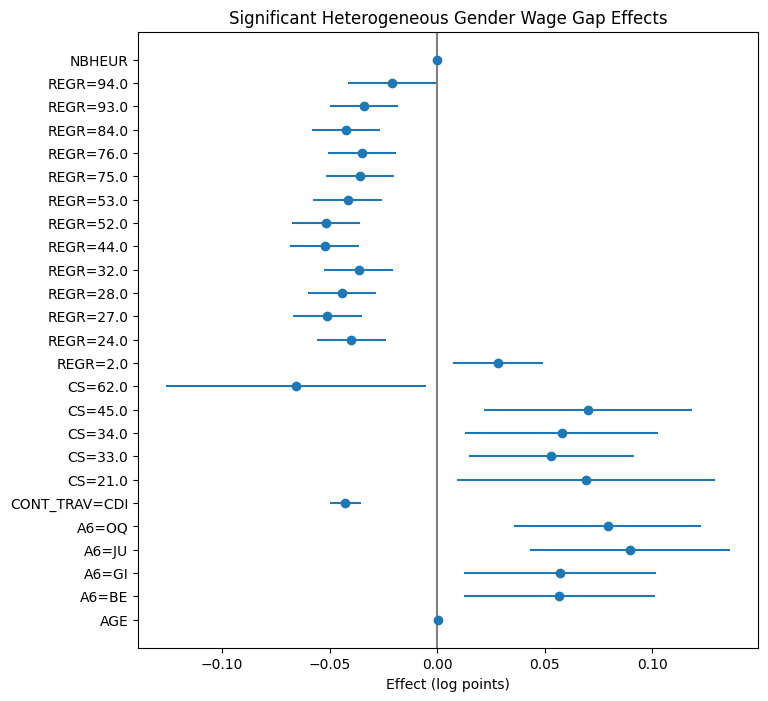

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.errorbar(
    sig["Estimate"],
    sig["term_clean"],
    xerr=1.96 * sig["Std. Error"],
    fmt='o'
)

plt.axvline(0, color="gray")
plt.title("Significant Heterogeneous Gender Wage Gap Effects")
plt.xlabel("Effect (log points)")
plt.show()

## Quantile Plot

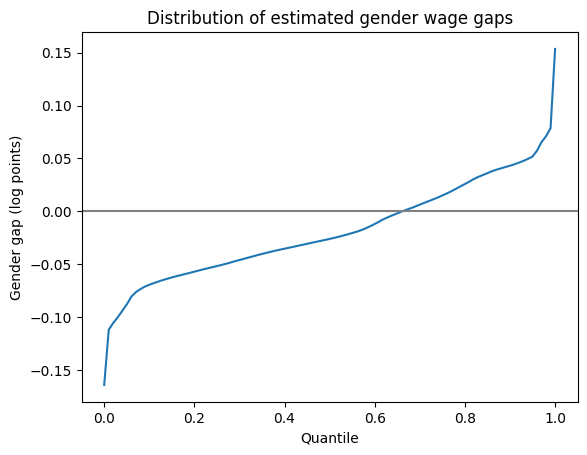

In [24]:
# predicted individual gender wage gaps
beta_x = X[interaction_cols] @ summary.set_index("term")["Estimate"]

women = Z["female"] == 1

gap_estimates = beta_x[women]

# quantile plot

q = np.linspace(0,1,100)
quantiles = np.quantile(gap_estimates, q)

plt.plot(q, quantiles)
plt.axhline(0, color="gray")
plt.xlabel("Quantile")
plt.ylabel("Gender gap (log points)")
plt.title("Distribution of estimated gender wage gaps")
plt.show()

- Bottom quantiles: Some women experience wage penalties of about 16% relative to comparable men.
- Middle of the distribution: Most women experience moderate wage penalties of around 2–3%
- Upper quantiles: Some women earn 15% more than comparable men.

#### This shows the gap is not universal.

## Distribution of Individual Gender Wage Gaps

In [25]:
print("Median gap:", np.median(gap_estimates))
print("Mean gap:", np.mean(gap_estimates))

print("Share negative:", np.mean(gap_estimates < 0))
print("Share positive:", np.mean(gap_estimates > 0))

Median gap: -0.026057447021916147
Mean gap: -0.01877823170753496
Share negative: 0.6607438142290485
Share positive: 0.33925618577095146


### Median: 0.026 ≈ −2.6 % −0.026≈−2.6%

So the typical woman earns about 2.6% less than a comparable man after accounting for heterogeneity.

### Mean: − 0.019 ≈−1.9 % −0.019≈−1.9%

The mean is slightly smaller than the median, meaning a few large positive gaps pull the mean upward.

### Share of gaps

- Two thirds of women experience a wage penalty
- One third experience no gap or even a wage advantage

## Variable Contributions

In [26]:
summary["group"] = summary["term"].str.extract(r"female:(\w+)")

summary.groupby("group")["Estimate"].mean()

group
AGE       0.000344
C        -0.001106
DUREE     0.000033
NBHEUR   -0.000017
Name: Estimate, dtype: float64

These are average heterogeneous effects across categories.

Age: 
- Very small positive effect: The gender wage gap increases slightly with age.
- But the magnitude is extremely small.

Hours worked (NBHEUR): 
- Slightly negative effect: Working more hours slightly reduces the gender wage gap.
- But again very small.

DUREE (tenure): 
- Tiny positive effect:
- Longer tenure slightly increases the gender gap.

C (categorical groups)
- Slightly negative: Some categories are associated with slightly smaller gender gaps.

## Baseline OLS Gender Wage Gap

In [27]:
import statsmodels.api as sm

X_avg = sm.add_constant(Z[["female"]])
model = sm.OLS(y, X_avg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6765.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:22:20   Log-Likelihood:             1.2413e+05
No. Observations:              463882   AIC:                        -2.483e+05
Df Residuals:                  463880   BIC:                        -2.482e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0198      0.000   2.79e+04      0.0

#### Women earn about 4.5% less than men on average.

## Bar Chart Ranking Heterogeneous Effects

<Axes: ylabel='term'>

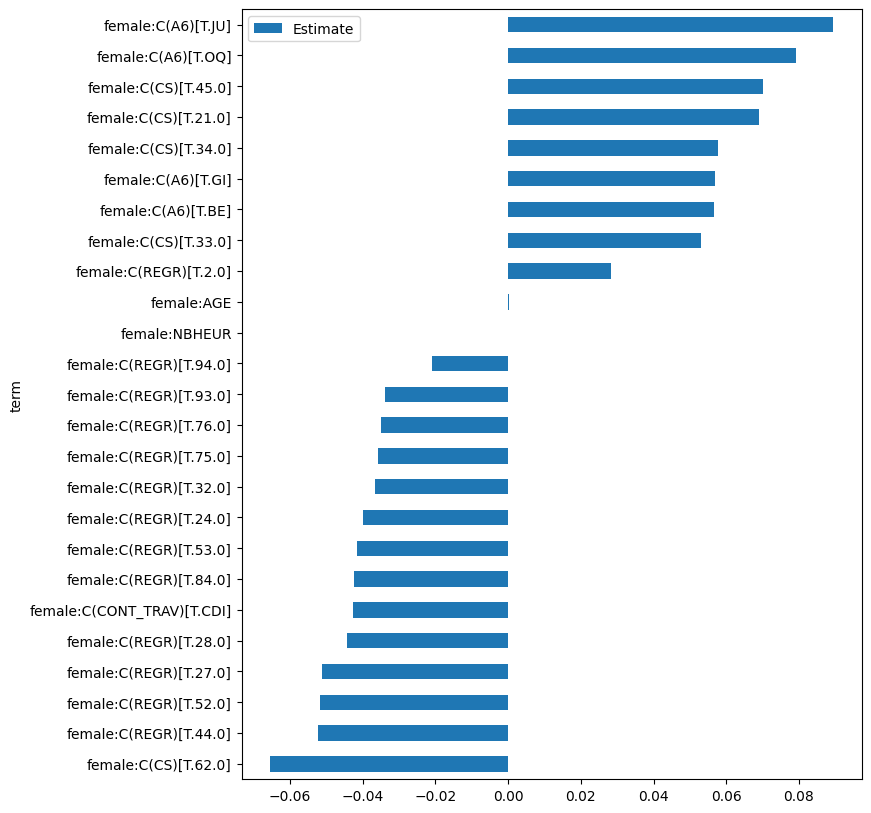

In [29]:
sig = summary[summary["p-value"] < 0.05]

sig.sort_values("Estimate").plot(
    x="term",
    y="Estimate",
    kind="barh",
    figsize=(8,10)
)

In [30]:
!aws s3 cp VA_Replication.ipynb s3://vanashkina-ensae/ML_for_Econometrics_Wage_Data/

upload failed: ./VA_Replication.ipynb to s3://vanashkina-ensae/ML_for_Econometrics_Wage_Data/VA_Replication.ipynb An error occurred (InvalidAccessKeyId) when calling the PutObject operation: The Access Key Id you provided does not exist in our records.
